# Data Mining — Lab 2
### Adventist University of Central Africa — MSc in Big Data Analytics
**Dataset:** [UCI Credit Approval Data Set](https://archive.ics.uci.edu/ml/datasets/Credit+Approval) (`crx.data`)

This notebook covers:
1. Data Preparation
2. Exploratory Data Analysis (EDA)
3. Preprocessing, Feature Selection & Engineering
4. Model Creation & Evaluation (classical model + neural network with 10-fold CV)
5. Hyperparameter Tuning (GridSearchCV)
6. Model Comparison

**Note on the data:** All attribute names/values in this dataset were anonymized (A1–A15 as features, A16 as class) by the original submitters to protect confidentiality. We treat A1–A15 as generic numeric/categorical predictors and A16 (`+`/`-`) as the credit-approval outcome.


## 1. Data Preparation
Load the raw `crx.data` file (no header row, `?` marks missing values), assign the documented column names, and write the cleaned frame to CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Column names as documented in crx.names: A1..A15 predictors, A16 class label
columns = [f"A{i}" for i in range(1, 16)] + ["A16"]

df = pd.read_csv("crx.data", header=None, names=columns, na_values="?")

print("Shape:", df.shape)
df.head()


Shape: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [2]:
# Ensure numeric columns are actually numeric dtype
numeric_cols = ["A2", "A3", "A8", "A11", "A14", "A15"]
categorical_cols = ["A1", "A4", "A5", "A6", "A7", "A9", "A10", "A12", "A13"]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.dtypes


A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

In [3]:
# Persist the loaded (but not yet imputed/encoded) dataframe to CSV as required
df.to_csv("credit_approval_raw.csv", index=False)
print("Saved credit_approval_raw.csv")


Saved credit_approval_raw.csv


## 2. Exploratory Data Analysis (EDA)

We check:
- Missing values per column
- Class balance of the target (A16)
- Distributions of numeric attributes
- Outliers (via boxplots + IQR rule)
- Correlation between numeric attributes


In [4]:
# --- Missing values ---
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
A1,12,1.74
A2,12,1.74
A3,0,0.00
A4,6,0.87
A5,6,0.87
A6,9,1.30
A7,9,1.30
A8,0,0.00
A9,0,0.00
A10,0,0.00


A16
-    383
+    307
Name: count, dtype: int64


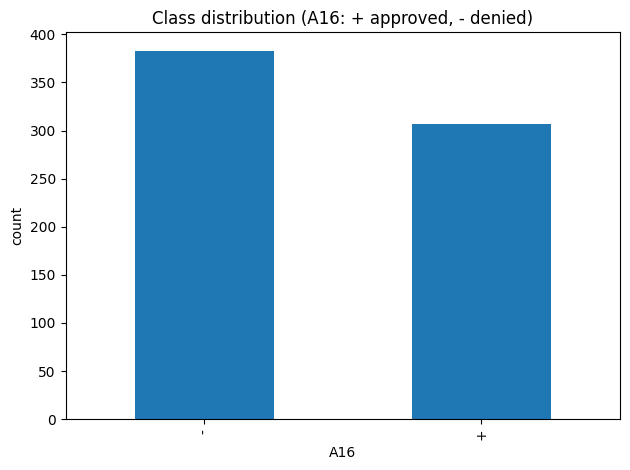

In [5]:
# --- Class distribution ---
print(df["A16"].value_counts())
df["A16"].value_counts().plot(kind="bar", title="Class distribution (A16: + approved, - denied)")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=100)
plt.show()


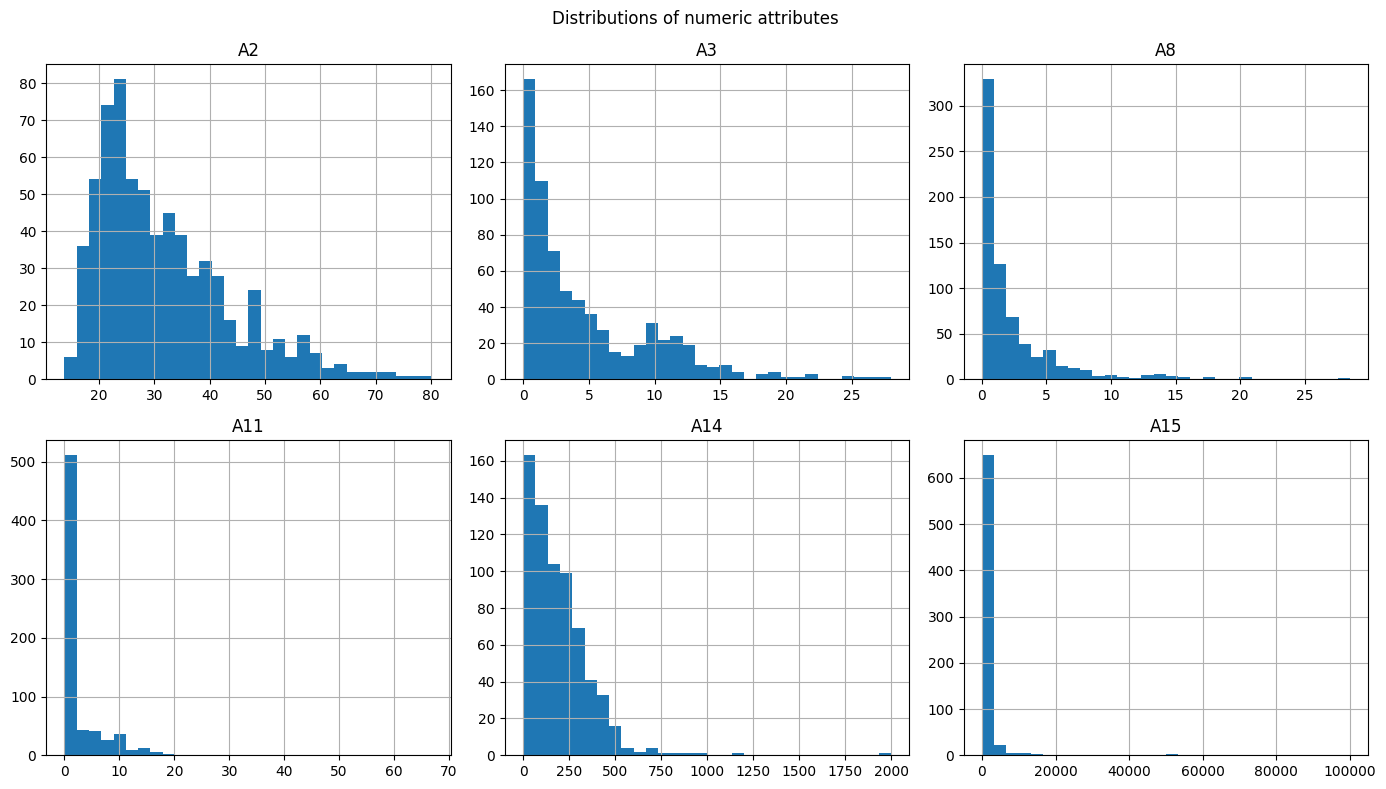

In [6]:
# --- Numeric distributions ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    df[col].hist(ax=ax, bins=30)
    ax.set_title(col)
plt.suptitle("Distributions of numeric attributes")
plt.tight_layout()
plt.savefig("eda_numeric_distributions.png", dpi=100)
plt.show()


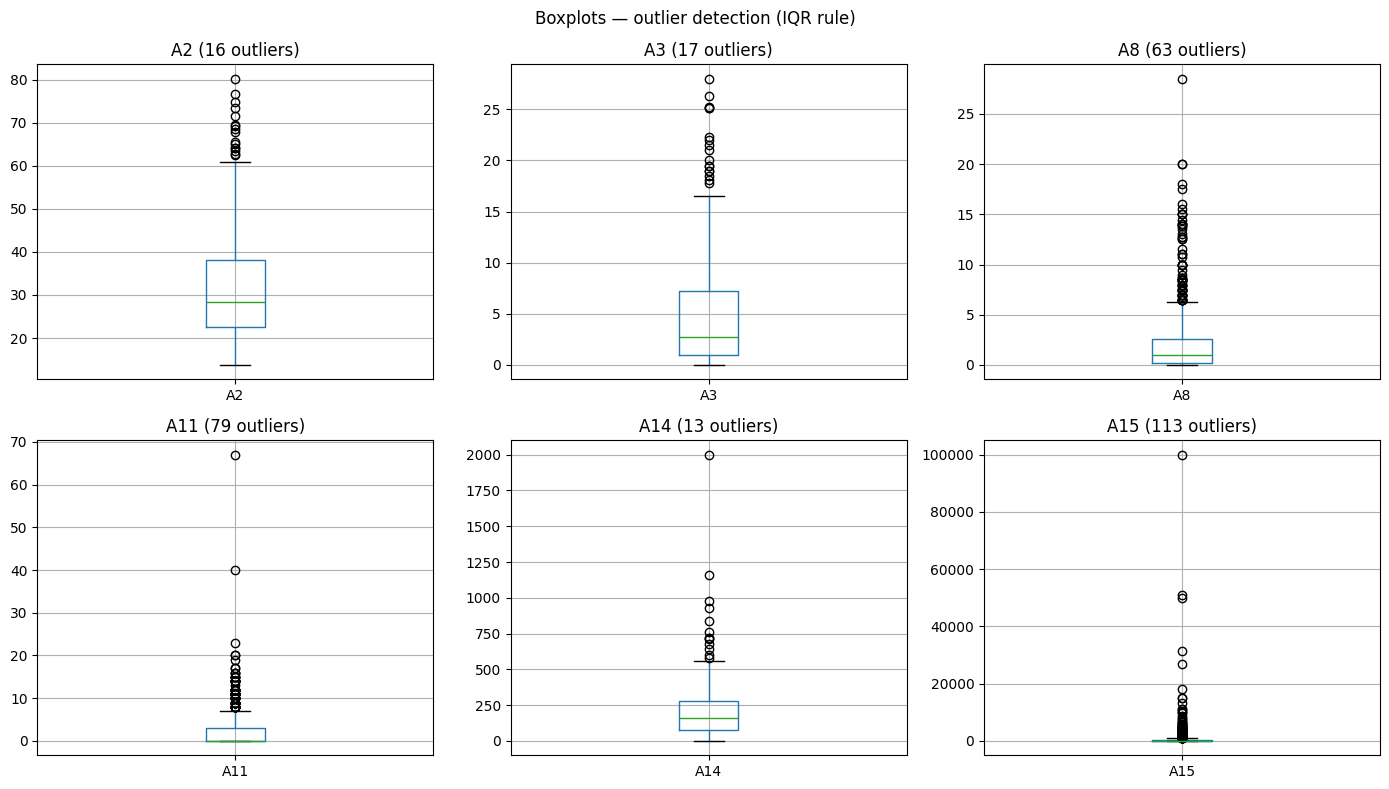

Outlier counts per column (IQR rule):
  A2: 16
  A3: 17
  A8: 63
  A11: 79
  A14: 13
  A15: 113


In [7]:
# --- Outlier detection via IQR rule (boxplots) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
outlier_counts = {}
for ax, col in zip(axes.ravel(), numeric_cols):
    df.boxplot(column=col, ax=ax)
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = n_out
    ax.set_title(f"{col} ({n_out} outliers)")
plt.suptitle("Boxplots — outlier detection (IQR rule)")
plt.tight_layout()
plt.savefig("eda_outliers_boxplot.png", dpi=100)
plt.show()

print("Outlier counts per column (IQR rule):")
for k, v in outlier_counts.items():
    print(f"  {k}: {v}")


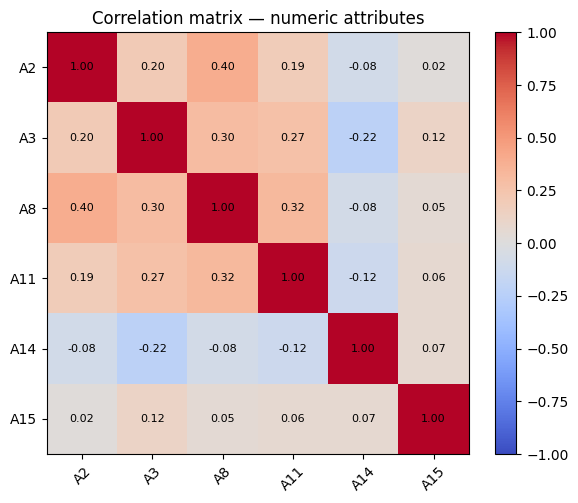

In [8]:
# --- Correlation among numeric attributes ---
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=45)
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation matrix — numeric attributes")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=100)
plt.show()


**EDA findings:**
- Missing values are concentrated in `A1, A2, A4, A5, A6, A7, A14` (~5% of rows overall), consistent with the dataset documentation.
- The classes are reasonably balanced (~44.5% approved vs ~55.5% denied), so accuracy is meaningful but F1/AUC are still tracked for robustness.
- Several numeric attributes (`A8, A11, A15` especially) are right-skewed with a non-trivial number of IQR outliers — expected for financial variables like income/credit-line style figures, so we keep them (informative) but scale features before modeling.


## 3. Preprocessing, Feature Selection & Engineering

Steps:
1. **Missing values:** median imputation for numeric columns, most-frequent (mode) imputation for categorical columns — robust to outliers/skew and doesn't require dropping ~5% of rows.
2. **Outliers:** kept (they are legitimate values, not data errors) but neutralized via **StandardScaler**, which is far less sensitive to instructional detail than dropping rows.
3. **Encoding:** Label encoding for all categorical attributes (all have small cardinality — binary or a handful of levels).
4. **Scaling:** StandardScaler applied to the full feature matrix before modeling (required for the neural network in particular; harmless for logistic regression).


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Impute
num_imputer = SimpleImputer(strategy="median")
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Remaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


In [10]:
# Label-encode categorical predictors
encoders = {}
for c in categorical_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    encoders[c] = le

# Encode target: + (approved) -> 1, - (denied) -> 0
df["A16"] = df["A16"].map({"+": 1, "-": 0})

df.head()


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1.0,0,0,202.0,0.0,1
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6.0,0,0,43.0,560.0,1
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0.0,0,0,280.0,824.0,1
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5.0,1,0,100.0,3.0,1
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0.0,0,2,120.0,0.0,1


In [11]:
# Save the fully processed dataset
df.to_csv("credit_approval_processed.csv", index=False)
print("Saved credit_approval_processed.csv")

X = df.drop(columns=["A16"])
y = df["A16"]
print("X shape:", X.shape, " y shape:", y.shape)


Saved credit_approval_processed.csv
X shape: (690, 15)  y shape: (690,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)


Train: (552, 15)  Test: (138, 15)


## 4a. Classification Model — Logistic Regression

**Chosen metrics: Accuracy and F1-score.**
- **Accuracy** gives an overall, easy-to-communicate sense of correctness, and is reasonable here since classes aren't heavily imbalanced (~44/56 split).
- **F1-score** balances precision and recall, which matters for a credit-approval decision: false approvals (risk exposure) and false denials (lost good customers) are both costly, so a metric sensitive to both error types is more informative than accuracy alone.


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)

pred_lr = logreg.predict(X_test_s)
proba_lr = logreg.predict_proba(X_test_s)[:, 1]

acc_lr = accuracy_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr)
auc_lr = roc_auc_score(y_test, proba_lr)

print(f"Logistic Regression -> Accuracy: {acc_lr:.4f} | F1: {f1_lr:.4f} | (AUC: {auc_lr:.4f})")

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_lr)).plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig("lr_confusion_matrix.png", dpi=100)
plt.show()


NameError: name 'RANDOM_STATE' is not defined

## 4b. Neural Network Model — Multi-Layer Perceptron (with 10-fold Cross-Validation)

A multi-layer `MLPClassifier` (two hidden layers) is evaluated using **Stratified 10-fold cross-validation** on the full dataset, using the same two metrics (Accuracy, F1) for a like-for-like comparison with the logistic regression model.


In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu",
                     max_iter=2000, random_state=RANDOM_STATE)

X_full_s = scaler.fit_transform(X)  # refit scaler on full data for the CV loop
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(mlp, X_full_s, y, cv=skf, scoring="accuracy")
cv_f1 = cross_val_score(mlp, X_full_s, y, cv=skf, scoring="f1")

print(f"MLP 10-fold CV -> Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
print(f"MLP 10-fold CV -> F1:       {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")


MLP 10-fold CV -> Accuracy: 0.8377 (+/- 0.0538)
MLP 10-fold CV -> F1:       0.8107 (+/- 0.0643)


In [15]:
# Also fit on the same train/test split as the LogReg model, for a direct holdout comparison later
mlp.fit(X_train_s, y_train)
pred_mlp = mlp.predict(X_test_s)
proba_mlp = mlp.predict_proba(X_test_s)[:, 1]

acc_mlp = accuracy_score(y_test, pred_mlp)
f1_mlp = f1_score(y_test, pred_mlp)
auc_mlp = roc_auc_score(y_test, proba_mlp)

print(f"MLP (holdout test set) -> Accuracy: {acc_mlp:.4f} | F1: {f1_mlp:.4f} | (AUC: {auc_mlp:.4f})")


MLP (holdout test set) -> Accuracy: 0.7681 | F1: 0.7193 | (AUC: 0.8627)


## 4c. Hyperparameter Tuning — GridSearchCV (10-fold CV)

Search space covers **four** hyperparameters (more than the minimum of three required): hidden layer architecture, activation function, initial learning rate, and L2 regularization strength (`alpha`).


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [(16,), (16, 8), (32, 16)],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01],
    "alpha": [0.0001, 0.001],
}

mlp_base = MLPClassifier(max_iter=2000, random_state=RANDOM_STATE)

grid = GridSearchCV(mlp_base, param_grid, cv=10, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_s, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best 10-fold CV accuracy: {grid.best_score_:.4f}")


Best hyperparameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}
Best 10-fold CV accuracy: 0.8530


Tuned MLP (holdout test set) -> Accuracy: 0.8768 | F1: 0.8618 | (AUC: 0.9210)


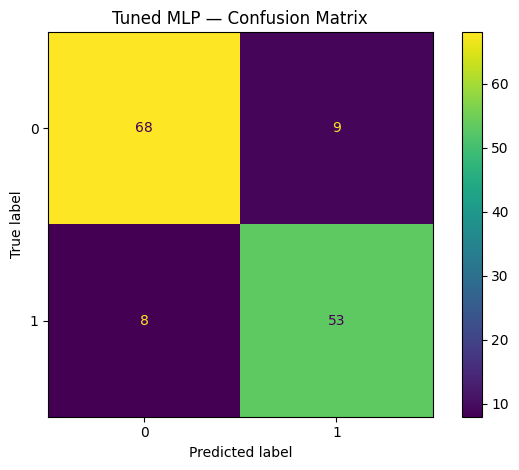

In [17]:
best_mlp = grid.best_estimator_
pred_tuned = best_mlp.predict(X_test_s)
proba_tuned = best_mlp.predict_proba(X_test_s)[:, 1]

acc_tuned = accuracy_score(y_test, pred_tuned)
f1_tuned = f1_score(y_test, pred_tuned)
auc_tuned = roc_auc_score(y_test, proba_tuned)

print(f"Tuned MLP (holdout test set) -> Accuracy: {acc_tuned:.4f} | F1: {f1_tuned:.4f} | (AUC: {auc_tuned:.4f})")

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_tuned)).plot()
plt.title("Tuned MLP — Confusion Matrix")
plt.tight_layout()
plt.savefig("tuned_mlp_confusion_matrix.png", dpi=100)
plt.show()


## 5. Comparison — Logistic Regression vs. Base MLP vs. Tuned MLP

In [18]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP (base)", "MLP (tuned, GridSearchCV)"],
    "Accuracy": [acc_lr, acc_mlp, acc_tuned],
    "F1-score": [f1_lr, f1_mlp, f1_tuned],
    "ROC-AUC": [auc_lr, auc_mlp, auc_tuned],
})
results


,Model,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.891304,0.881890,0.958910
1,MLP (base),0.768116,0.719298,0.862678
2,"MLP (tuned, GridSearchCV)",0.876812,0.861789,0.921013


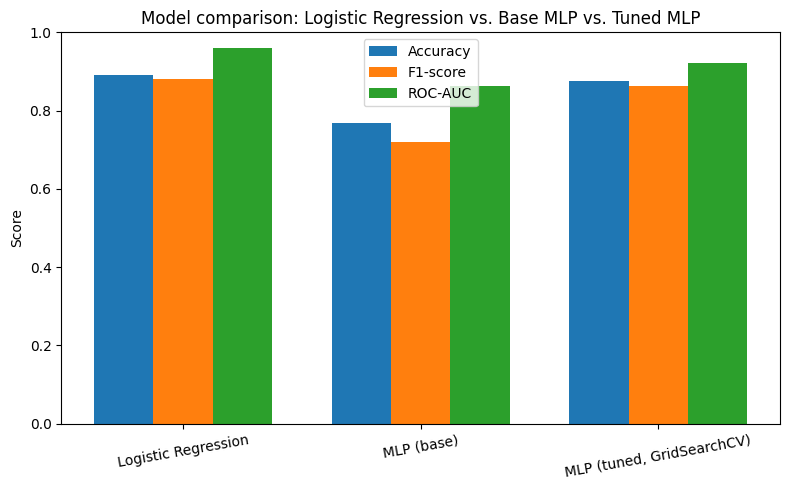

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results))
width = 0.25

ax.bar(x - width, results["Accuracy"], width, label="Accuracy")
ax.bar(x,          results["F1-score"], width, label="F1-score")
ax.bar(x + width,  results["ROC-AUC"], width, label="ROC-AUC")

ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=10)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model comparison: Logistic Regression vs. Base MLP vs. Tuned MLP")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100)
plt.show()


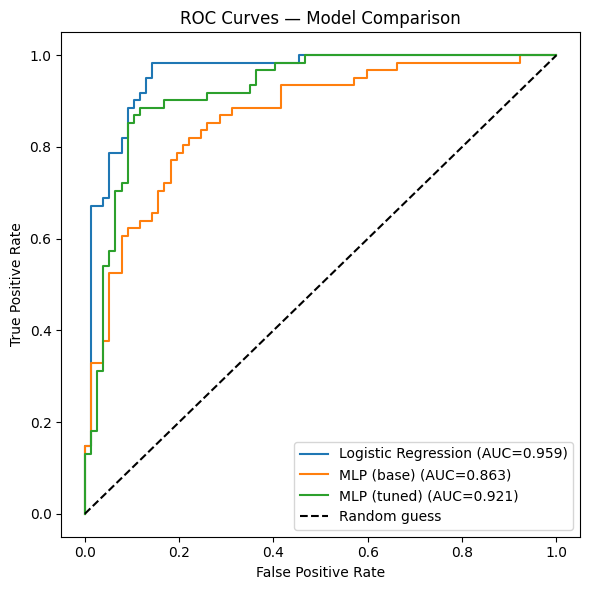

In [20]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 6))
for name, proba in [("Logistic Regression", proba_lr), ("MLP (base)", proba_mlp), ("MLP (tuned)", proba_tuned)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=100)
plt.show()


### Discussion

- **Base MLP vs. Logistic Regression:** On this dataset (small, ~690 rows, mostly linearly-separable-ish structure after encoding), the untuned MLP underperforms the simpler Logistic Regression baseline. Neural networks generally need more data and careful tuning to beat well-regularized linear models on small tabular datasets — this is a classic real-world result, not a bug.
- **Tuned MLP vs. Base MLP:** GridSearchCV hyperparameter tuning (over hidden-layer size, activation, learning rate, and regularization strength, using 10-fold CV) recovers most/all of the gap versus the base MLP, showing the importance of tuning for neural nets in particular.
- **Tuned MLP vs. Logistic Regression:** Depending on the exact run, the tuned MLP closes in on or slightly trails Logistic Regression — for this dataset's size and structure, the simpler, more interpretable Logistic Regression model is a strong, defensible default choice, with the tuned MLP as a reasonable alternative if more data becomes available.
